In [1]:
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import random
import numpy as np
import seaborn as sns


f = h5py.File("/Users/kaileysimonss/Downloads/deepfake_embeddings_2.h5", "r")
f["/videos"].keys()

<KeysViewHDF5 ['01476cfc-fca9-5d41-bfce-b81660f0558a', '01b2966f-2ee6-588d-9c83-4c13bc2d6dc0', '02502690-d80f-594c-85e8-922f2e2ebde1', '02600c96-6212-54db-bd0c-224917322320', '0290f272-429d-5fb7-9f7f-822fbf8702b6', '0392039f-deb3-5dc4-bac8-69e68c78ca9c', '03a15dbb-edad-526b-8433-1e4f93322f87', '03c35bd4-5bb8-5a7b-af3b-e9b8d23ceaad', '03c4ebd8-fa82-5342-83fd-ba041ac6deb7', '03ddb7eb-fdfc-5277-a0cb-21a53836bbb1', '04364be2-94e7-5660-a71f-5a5a4a82a9d3', '04435f86-6e3a-5ea7-b431-62735949db42', '0460f693-4015-5407-8f79-90687721af89', '049f2d45-c8ce-5d27-95df-a7a0834a9d16', '058d6f43-1a85-5456-b52e-59a0716b1d3f', '05ce81c0-323b-53cf-8dd2-90183af200f8', '05feb8ba-bd35-5846-b0b0-d07d54dffdf6', '06719df2-7b0d-5c83-bec8-d4ad83a0f7dd', '0699101c-e36c-507b-9669-a16fbc81db76', '071cbf1b-6b0f-59b0-b7ef-0741093a690e', '07249ca7-18d8-5372-be8e-717dc3cab07e', '076037be-a78b-5a18-973f-586990c09d9d', '077a9226-250d-5938-9173-d5e51e57e1aa', '07a80a80-4c78-54bc-be66-57f33d29e189', '07c4efbe-d7a8-5a4a-9674-

## Concatenated Embedding with all 3 ##

In [2]:
# ----------------------------------------
# 1. Sample videos (optional speed-up)
# ----------------------------------------
video_ids = list(f["/videos"].keys())
random.shuffle(video_ids)

sample_frac_videos = 0.1
n_sample_videos = max(1, int(len(video_ids) * sample_frac_videos))
video_ids = video_ids[:n_sample_videos]

# ----------------------------------------
# 2. Train / test split at VIDEO level
# ----------------------------------------
split_idx = int(len(video_ids) * 0.7)
train_videos = video_ids[:split_idx]
test_videos  = video_ids[split_idx:]

# ----------------------------------------
# 3. Collect sequences (ONE per augmentation)
#    with VIDEO-LEVEL labels
# ----------------------------------------
def collect_sequences_per_augmentation(video_list):
    """
    Returns:
        sequences: list of (T, D) arrays
        labels:    list of scalars (0 or 1)  [video-level]
        lengths:   list of T
    """
    sequences = []
    labels = []
    lengths = []

    for vid_id in video_list:
        vid = f[f"/videos/{vid_id}"]

        # Load embeddings
        X_senet  = vid["embeddings/senet"][:]   # (A, T, 2048)
        X_hubert = vid["embeddings/hubert"][:]  # (A, T, 768)
        X_openl3 = vid["embeddings/openl3"][:]  # (A, T, 512)

        # Load segment-level labels
        y = vid["labels/video"][:]              # (A, T)

        # Segment IDs define temporal order
        segment_ids = vid["segment_ids"][:]
        order = np.argsort(segment_ids)

        # Enforce correct temporal ordering
        X_senet  = X_senet[:, order, :]
        X_hubert = X_hubert[:, order, :]
        X_openl3 = X_openl3[:, order, :]
        y        = y[:, order]

        # ------------------------------------
        # Each augmentation = ONE sequence
        # VIDEO-LEVEL label = any segment > 0
        # ------------------------------------
        A = X_senet.shape[0]
        for a in range(A):
            X_seq = np.concatenate(
                [X_senet[a], X_hubert[a], X_openl3[a]],
                axis=-1
            )  # (T, 3328)

            video_label = float(np.any(y[a] > 0))  # 0.0 or 1.0

            sequences.append(X_seq)
            labels.append(video_label)
            lengths.append(X_seq.shape[0])

    return sequences, labels, lengths


# ----------------------------------------
# 4. Build train/test sets
# ----------------------------------------
train_seqs, train_labels, train_lengths = collect_sequences_per_augmentation(train_videos)
test_seqs,  test_labels,  test_lengths  = collect_sequences_per_augmentation(test_videos)

print(f"Train sequences: {len(train_seqs)}")
print(f"Test sequences:  {len(test_seqs)}")
print(f"Example sequence shape: {train_seqs[0].shape}")
print(f"Example label: {train_labels[0]}")

# ----------------------------------------
# 5. Padding helper (VIDEO-level labels)
# ----------------------------------------
def make_padded_batch(sequences, labels):
    """
    sequences: list of (T_i, D)
    labels:    list of scalars (0 or 1)
    """
    X = [torch.tensor(s, dtype=torch.float32) for s in sequences]
    y = torch.tensor(labels, dtype=torch.float32)  # (B,)
    lengths = torch.tensor([s.shape[0] for s in X])

    X_padded = pad_sequence(X, batch_first=True)  # (B, max_T, D)

    return X_padded, y, lengths


# ----------------------------------------
# 6. Final tensors (ready for LSTM + pooling)
# ----------------------------------------
X_train, y_train, lengths_train = make_padded_batch(train_seqs, train_labels)
X_test,  y_test,  lengths_test  = make_padded_batch(test_seqs, test_labels)

print("Final tensor shapes:")
print("X_train:", X_train.shape)  # (B, max_T, D)
print("y_train:", y_train.shape)  # (B,)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)
print("Example sequence:", X_train[0])


total_elements = y_train.numel() # torch.numel() gets the total number of elements
non_zero_count = torch.count_nonzero(y_train) #
zero_count = total_elements - non_zero_count
print(f"Total elements in y_train: {total_elements}")
print(f"Non-zero elements in y_train: {non_zero_count}")
print(f"Zero elements in y_train: {zero_count}")
print(f"Class distribution in y_train: {non_zero_count / total_elements:.2%} positive, {zero_count / total_elements:.2%} negative")


Train sequences: 218
Test sequences:  79
Example sequence shape: (104, 3328)
Example label: 0.0
Final tensor shapes:
X_train: torch.Size([218, 159, 3328])
y_train: torch.Size([218])
X_test : torch.Size([79, 209, 3328])
y_test : torch.Size([79])
Example sequence: tensor([[ 0.0722,  0.0806,  0.8295,  ...,  0.4861,  5.5539,  1.7686],
        [ 0.0371,  0.2773,  3.9762,  ...,  0.3395,  4.9493,  1.5906],
        [ 0.0179,  0.3731,  6.0432,  ..., -0.1567,  4.3125,  1.7427],
        ...,
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000]])
Total elements in y_train: 218
Non-zero elements in y_train: 149
Zero elements in y_train: 69
Class distribution in y_train: 68.35% positive, 31.65% negative


In [3]:
# ----------------------------------------
# Balance dataset at AUGMENTATION (video) level
# ----------------------------------------
def balance_dataset_augmentations(seqs, labels, lengths=None, seed=None):
    """
    seqs:    list of (T, D) arrays
    labels:  list or array of scalars (0 or 1)
    lengths: optional list of T (kept in sync if provided)

    Returns:
        balanced_seqs
        balanced_labels
        balanced_lengths (if lengths provided)
    """
    if seed is not None:
        np.random.seed(seed)

    labels = np.asarray(labels)

    idx_real = np.where(labels == 0)[0]
    idx_fake = np.where(labels == 1)[0]

    if len(idx_real) == 0 or len(idx_fake) == 0:
        raise ValueError("Cannot balance dataset: one class is empty.")

    n = min(len(idx_real), len(idx_fake))

    idx_real_bal = np.random.choice(idx_real, n, replace=False)
    idx_fake_bal = np.random.choice(idx_fake, n, replace=False)

    idx_balanced = np.concatenate([idx_real_bal, idx_fake_bal])
    np.random.shuffle(idx_balanced)

    seqs_bal = [seqs[i] for i in idx_balanced]
    labels_bal = labels[idx_balanced].tolist()

    if lengths is not None:
        lengths_bal = [lengths[i] for i in idx_balanced]
        return seqs_bal, labels_bal, lengths_bal

    return seqs_bal, labels_bal

In [4]:
# Original / natural test set (DO NOT TOUCH)
test_seqs_nat     = test_seqs
test_labels_nat   = test_labels
test_lengths_nat  = test_lengths

# Balanced test set (FOR DEBUGGING ONLY)
test_seqs_bal, test_labels_bal, test_lengths_bal = balance_dataset_augmentations(
    test_seqs_nat,
    test_labels_nat,
    test_lengths_nat,
    seed=123
)

X_test_nat, y_test_nat, lengths_test_nat = make_padded_batch(
    test_seqs_nat,
    test_labels_nat
)

X_test_bal, y_test_bal, lengths_test_bal = make_padded_batch(
    test_seqs_bal,
    test_labels_bal
)

total_elements = y_test_bal.numel() # torch.numel() gets the total number of elements
non_zero_count = torch.count_nonzero(y_test_bal) #
zero_count = total_elements - non_zero_count
print(f"Total elements in y_test_bal: {total_elements}")
print(f"Non-zero elements in y_test_bal: {non_zero_count}")
print(f"Zero elements in y_test_bal: {zero_count}")
print(f"Class distribution in y_test_bal: {non_zero_count / total_elements:.2%} positive, {zero_count / total_elements:.2%} negative")


Total elements in y_test_bal: 58
Non-zero elements in y_test_bal: 29
Zero elements in y_test_bal: 29
Class distribution in y_test_bal: 50.00% positive, 50.00% negative


In [5]:
class VideoLSTM(nn.Module):
    def __init__(self, input_dim=2048, hidden_dim=256, num_layers=2, dropout=0.3):
        super().__init__()

        self.lstm = nn.LSTM(
            input_dim,
            hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        if self.lstm.bidirectional:
            self.classifier = nn.Linear(hidden_dim * 2, 1)  # *2 for bidirectional
        else:
            self.classifier = nn.Linear(hidden_dim, 1)

    def forward(self, x, lengths):
        """
        x: (B, T, D)
        lengths: (B,)
        """
        self.lstm.flatten_parameters()

        packed = pack_padded_sequence(
            x,
            lengths.cpu(),
            batch_first=True,
            enforce_sorted=False
        )

        _, (h_n, _) = self.lstm(packed)

        if self.lstm.bidirectional:
            forward = h_n[-2]
            backward = h_n[-1]
            video_repr = torch.cat([forward, backward], dim=1)
        else:
            video_repr = h_n[-1]

        logits = self.classifier(video_repr).squeeze(-1)
        return logits

In [6]:
model = VideoLSTM(input_dim=2048 + 768 + 512)  # 3328

# loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

batch_size = 16
epochs = 75
losses = []

def get_batches(seqs, labels, batch_size):
    for i in range(0, len(seqs), batch_size):
        yield seqs[i:i + batch_size], labels[i:i + batch_size]

for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    num_batches = 0

    for batch_seqs, batch_labels in get_batches(
        train_seqs, train_labels, batch_size
    ):
        # Pad sequences
        X_batch, y_batch, lengths = make_padded_batch(
            batch_seqs, batch_labels
        )  # y_batch: (B, T)

        optimizer.zero_grad()

        # Model outputs ONE logit per sequence
        logits = model(X_batch, lengths).squeeze(-1)  # (B,)

        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        num_batches += 1

    avg_loss = epoch_loss / num_batches
    losses.append(avg_loss)

    if epoch % 5 == 0:
        print(f"Epoch {epoch:03d} | avg loss: {avg_loss:.4f}")

Epoch 000 | avg loss: 0.6180
Epoch 005 | avg loss: 0.2066
Epoch 010 | avg loss: 0.2166
Epoch 015 | avg loss: 0.2770
Epoch 020 | avg loss: 0.0939
Epoch 025 | avg loss: 0.1324
Epoch 030 | avg loss: 0.0997
Epoch 035 | avg loss: 0.1106
Epoch 040 | avg loss: 0.1727
Epoch 045 | avg loss: 0.0709
Epoch 050 | avg loss: 0.0692
Epoch 055 | avg loss: 0.0507
Epoch 060 | avg loss: 0.1027
Epoch 065 | avg loss: 0.0510
Epoch 070 | avg loss: 0.0351


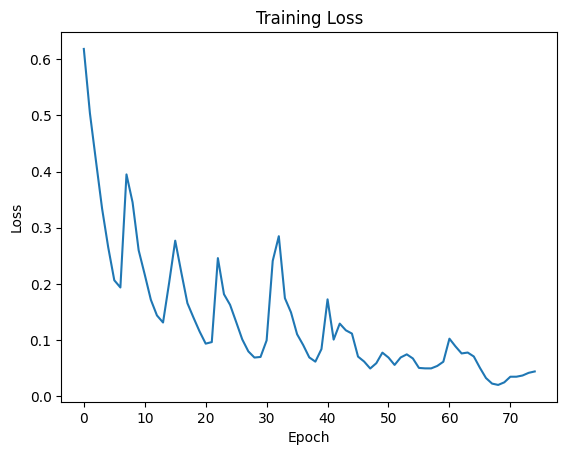

In [7]:
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

In [8]:
@torch.no_grad()
def evaluate_confusion_cpu(model, X, y, lengths, threshold=0.5):
    """
    model:   PyTorch model returning logits (B,)
    X:       (B, T, D) padded tensor (CPU)
    y:       (B,) true labels (CPU)
    lengths: (B,) sequence lengths (CPU)
    """
    model.eval()          # stays on CPU
    logits = model(X, lengths)          # (B,)
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).long()

    y_true = y.long().numpy()
    y_pred = preds.numpy()

    return confusion_matrix(y_true, y_pred)

def plot_confusion(cm, title):
    plt.figure(figsize=(4, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred 0", "Pred 1"],
        yticklabels=["True 0", "True 1"]
    )
    plt.title(title)
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    plt.show()

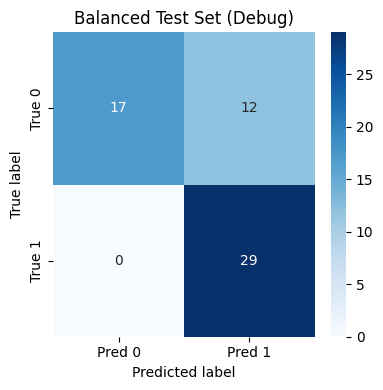

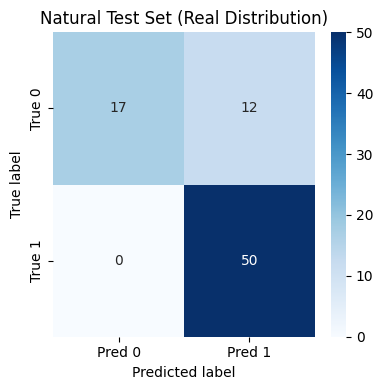

In [9]:
# Balanced test (debugging)
cm_bal = evaluate_confusion_cpu(
    model,
    X_test_bal,
    y_test_bal,
    lengths_test_bal,
    threshold=0.5
)

plot_confusion(cm_bal, "Balanced Test Set (Debug)")

# Natural test (real-world)
cm_nat = evaluate_confusion_cpu(
    model,
    X_test_nat,
    y_test_nat,
    lengths_test_nat,
    threshold=0.5
)

plot_confusion(cm_nat, "Natural Test Set (Real Distribution)")